# 手工搭建一个可运行的多源网络

这个 notebook 只演示当前已经实现的直接连接路径：

```text
Cell.place() -> SynapseView -> connect() -> Network.run()
```

我们会创建两个具有真实 HH 动力学的上游群体、一个下游群体、两种突触模型，以及 live 和 scheduled 两类事件源，并统一使用直接的 source-to-synapse 连接。

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the braincell repository.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import braincell
from braincell import mech
from braincell.filter import AllRegion, at

brainstate.environ.set(precision=64)
print("braincell version:", braincell.__version__)

braincell version: 0.1.0


## 1. 一个正常的三分支 HH cell

三个 population 使用相同的 soma + 两条 dendrite 形态。`CVPerBranchList((1, 4, 5))` 产生 10 个 CV；所有电压和膜参数都显式使用浮点量和单位。

In [2]:
def build_morphology():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma",
    )
    dend_a = braincell.Branch.from_lengths(
        lengths=[160.0] * u.um, radii=[2.0, 1.0] * u.um, type="basal_dendrite",
    )
    dend_b = braincell.Branch.from_lengths(
        lengths=[220.0] * u.um, radii=[2.5, 0.8] * u.um, type="apical_dendrite",
    )
    morphology = braincell.Morphology.from_root(soma, name="soma")
    morphology.soma.dend_a = dend_a
    morphology.soma.dend_b = dend_b
    return morphology


def build_hh_population(name, size):
    cell = braincell.Cell(
        build_morphology(),
        cv_policy=braincell.CVPerBranchList((1, 4, 5)),
        pop_size=(size,),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        solver="staggered",
        name=name,
    )
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * (u.uF / u.cm**2),
            axial_resistivity=100.0 * (u.ohm * u.cm),
        ),
        mech.Ion("SodiumFixed", E=50.0 * u.mV),
        mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        mech.Channel("Na_HH1952", g_max=120.0 * (u.mS / u.cm**2)),
        mech.Channel("K_HH1952", g_max=36.0 * (u.mS / u.cm**2)),
        mech.Channel("IL", g_max=0.3 * (u.mS / u.cm**2), E=-54.387 * u.mV),
    )
    assert cell.n_cv == 10
    return cell


exc = build_hh_population("exc", size=4)
inh = build_hh_population("inh", size=3)
post = build_hh_population("post", size=4)

pd.DataFrame({
    "population": ["exc", "inh", "post"],
    "cells": [4, 3, 4],
    "cv_per_cell": [exc.n_cv, inh.n_cv, post.n_cv],
})

,population,cells,cv_per_cell
0,exc,4,10
1,inh,3,10
2,post,4,10


## 2. Live source 和两类 postsynaptic synapse

`exc` 和 `inh` 通过不同时间的短电流脉冲自然产生 spike。下游每个 cell 放置两个 AMPA-like `ExpSyn` 和两个 GABA-like `Exp2Syn`。同一类型最终进入一个 SoA runtime layout，但每个逻辑实例仍保留自己的位置和参数。

In [3]:
exc.place(
    at("soma", 0.5),
    mech.CurrentClamp(
        delay=np.asarray([5.0, 7.0, 9.0, 11.0]) * u.ms,
        durations=0.1 * u.ms,
        amplitudes=1.0 * u.nA,
    ),
)
inh.place(
    at("soma", 0.5),
    mech.CurrentClamp(
        delay=np.asarray([14.0, 16.0, 18.0]) * u.ms,
        durations=0.1 * u.ms,
        amplitudes=1.0 * u.nA,
    ),
)

ampa = mech.SynapseSpec(
    "ExpSyn", name="ampa",
    tau=np.asarray([1.5, 3.0]) * u.ms,
    e=0.0 * u.mV,
)
gaba = mech.SynapseSpec(
    "Exp2Syn", name="gaba",
    tau1=np.asarray([0.5, 0.8]) * u.ms,
    tau2=np.asarray([5.0, 8.0]) * u.ms,
    e=-80.0 * u.mV,
)

post.place(
    at("dend_a", 0.25) + at("dend_b", 0.70),
    ampa,
    mech.MechanismProbe(name="g_ampa", mechanism="ampa", field="g"),
)
post.place(
    at("soma", 0.5) + at("dend_a", 0.65),
    gaba,
    mech.MechanismProbe(name="g_gaba", mechanism="gaba", field="g"),
)
post.place(at("soma", 0.5), mech.StateProbe(name="v_soma", field="v"))

ampa_targets = post.synapses[ampa]
gaba_targets = post.synapses[gaba]
assert len(ampa_targets) == 8
assert len(gaba_targets) == 8

In [4]:
def synapse_metadata(view):
    return pd.DataFrame({
        "synapse_id": view.id,
        "cell_id": view.population_index,
        "type": view.synapse_type,
        "name": view.name,
        "branch_id": view.branch_id,
        "branch_x": view.branch_x,
        "cv_id": view.cv_id,
    })


ampa_table = synapse_metadata(ampa_targets)
ampa_table["tau_ms"] = ampa_targets.tau.to_decimal(u.ms)
ampa_table["tau1_ms"] = np.nan
ampa_table["tau2_ms"] = np.nan
ampa_table["e_mV"] = ampa_targets.e.to_decimal(u.mV)

gaba_table = synapse_metadata(gaba_targets)
gaba_table["tau_ms"] = np.nan
gaba_table["tau1_ms"] = gaba_targets.tau1.to_decimal(u.ms)
gaba_table["tau2_ms"] = gaba_targets.tau2.to_decimal(u.ms)
gaba_table["e_mV"] = gaba_targets.e.to_decimal(u.mV)

synapse_table = (
    pd.concat([ampa_table, gaba_table], ignore_index=True)
    .sort_values(["cell_id", "type", "synapse_id"])
    .reset_index(drop=True)
)
synapse_table

,synapse_id,cell_id,type,name,branch_id,branch_x,cv_id,tau_ms,tau1_ms,tau2_ms,e_mV
0,16,0,Exp2Syn,gaba,0,0.50,0,NaN,0.5,5.0,-80.0
1,24,0,Exp2Syn,gaba,1,0.65,3,NaN,0.8,8.0,-80.0
2,0,0,ExpSyn,ampa,1,0.25,2,1.5,NaN,NaN,0.0
3,8,0,ExpSyn,ampa,2,0.70,8,3.0,NaN,NaN,0.0
4,17,1,Exp2Syn,gaba,0,0.50,0,NaN,0.5,5.0,-80.0
5,25,1,Exp2Syn,gaba,1,0.65,3,NaN,0.8,8.0,-80.0
6,1,1,ExpSyn,ampa,1,0.25,2,1.5,NaN,NaN,0.0
7,9,1,ExpSyn,ampa,2,0.70,8,3.0,NaN,NaN,0.0
8,18,2,Exp2Syn,gaba,0,0.50,0,NaN,0.5,5.0,-80.0
9,26,2,Exp2Syn,gaba,1,0.65,3,NaN,0.8,8.0,-80.0


## 3. 四组手工连接

`connect()` 的两端都是有序 view。两端等长时逐行 zip；要表达汇聚、发散或任意稀疏关系，就显式重复 source 或 synapse 的索引。下面的 `pick_targets()` 只把 `(post cell id, cell 内局部 synapse id)` 翻译成当前 `SynapseView` 的行号。

In [5]:
def pick_targets(view, pairs):
    selected = []
    population_index = np.asarray(view.population_index)
    for cell_id, local_synapse_id in pairs:
        candidates = np.flatnonzero(population_index == cell_id)
        selected.append(int(candidates[local_synapse_id]))
    return view[np.asarray(selected)]


exc_live = braincell.connect(
    "exc_live",
    source=exc.event_outputs["spike"][[0, 0, 1, 1, 2, 2, 3, 3]],
    synapse=pick_targets(ampa_targets, [
        (0, 0), (1, 1), (1, 0), (2, 1),
        (2, 0), (3, 1), (3, 0), (0, 1),
    ]),
    weight=np.linspace(0.05, 0.12, 8) * u.uS,
    delay=np.arange(8, dtype=float) * 0.2 * u.ms,
)

inh_live = braincell.connect(
    "inh_live",
    source=inh.event_outputs["spike"][[0, 0, 1, 1, 2, 2]],
    synapse=pick_targets(gaba_targets, [
        (0, 0), (1, 1), (1, 0), (2, 1), (2, 0), (3, 1),
    ]),
    weight=np.linspace(0.04, 0.09, 6) * u.uS,
    delay=np.arange(1, 7, dtype=float) * 0.2 * u.ms,
)

background = braincell.NetStim(
    size=4,
    start=np.asarray([2.0, 3.0, 4.0, 5.0]) * u.ms,
    number=3,
    interval=12.0 * u.ms,
    noise=0.1,
    seed=7,
    name="background",
)
background_input = braincell.connect(
    "background",
    source=background,
    synapse=pick_targets(ampa_targets, [(0, 1), (1, 1), (2, 1), (3, 1)]),
    weight=0.03 * u.uS,
    delay=0.5 * u.ms,
)

scheduled = braincell.EventSequence(
    size=2,
    events=braincell.EventTable(
        source_index=[0, 0, 1, 1],
        time=np.asarray([12.0, 24.0, 13.0, 25.0]) * u.ms,
    ),
    name="scheduled",
)
scheduled_input = braincell.connect(
    "scheduled",
    source=scheduled[[0, 0, 1, 1]],
    synapse=pick_targets(gaba_targets, [(0, 1), (2, 0), (1, 1), (3, 0)]),
    weight=0.025 * u.uS,
    delay=np.asarray([0.0, 0.5, 1.0, 1.5]) * u.ms,
)

post.connections

ConnectionView(cell=Cell(name='post'), rows=22, connects=4)
  exc_live: CellSpikeSource(exc.spike) -> ExpSyn(ampa), rows=8
  inh_live: CellSpikeSource(inh.spike) -> Exp2Syn(gaba), rows=6
  background: NetStim(background) -> ExpSyn(ampa), rows=4
  scheduled: EventSequence(scheduled) -> Exp2Syn(gaba), rows=4

In [6]:
def connection_frame(view):
    return pd.DataFrame({
        "connection_id": view.id,
        "connection": view.connect_name,
        "source_type": view.source_type,
        "source_name": view.source_name,
        "source_id": view.source_index,
        "post_cell": view.synapse.population_index,
        "synapse_id": view.synapse_id,
        "synapse_type": view.synapse_type,
        "synapse_name": view.synapse_name,
        "weight_uS": view.weight.to_decimal(u.uS),
        "delay_ms": view.delay.to_decimal(u.ms),
    })


connection_table = pd.concat(
    [connection_frame(post.connections[name]) for name in post.connections.connect_names],
    ignore_index=True,
)
assert post.connections.connect_names == (
    "exc_live", "inh_live", "background", "scheduled",
)
assert connection_table.groupby("connection").size().to_dict() == {
    "background": 4, "exc_live": 8, "inh_live": 6, "scheduled": 4,
}
connection_table

,connection_id,connection,source_type,source_name,source_id,post_cell,synapse_id,synapse_type,synapse_name,weight_uS,delay_ms
0,0,exc_live,CellSpikeSource,exc.spike,0,0,0,ExpSyn,ampa,0.050,0.0
1,1,exc_live,CellSpikeSource,exc.spike,0,1,9,ExpSyn,ampa,0.060,0.2
2,2,exc_live,CellSpikeSource,exc.spike,1,1,1,ExpSyn,ampa,0.070,0.4
3,3,exc_live,CellSpikeSource,exc.spike,1,2,10,ExpSyn,ampa,0.080,0.6
4,4,exc_live,CellSpikeSource,exc.spike,2,2,2,ExpSyn,ampa,0.090,0.8
5,5,exc_live,CellSpikeSource,exc.spike,2,3,11,ExpSyn,ampa,0.100,1.0
6,6,exc_live,CellSpikeSource,exc.spike,3,3,3,ExpSyn,ampa,0.110,1.2
7,7,exc_live,CellSpikeSource,exc.spike,3,0,8,ExpSyn,ampa,0.120,1.4
8,8,inh_live,CellSpikeSource,inh.spike,0,0,16,Exp2Syn,gaba,0.040,0.2
9,9,inh_live,CellSpikeSource,inh.spike,0,1,25,Exp2Syn,gaba,0.050,0.4


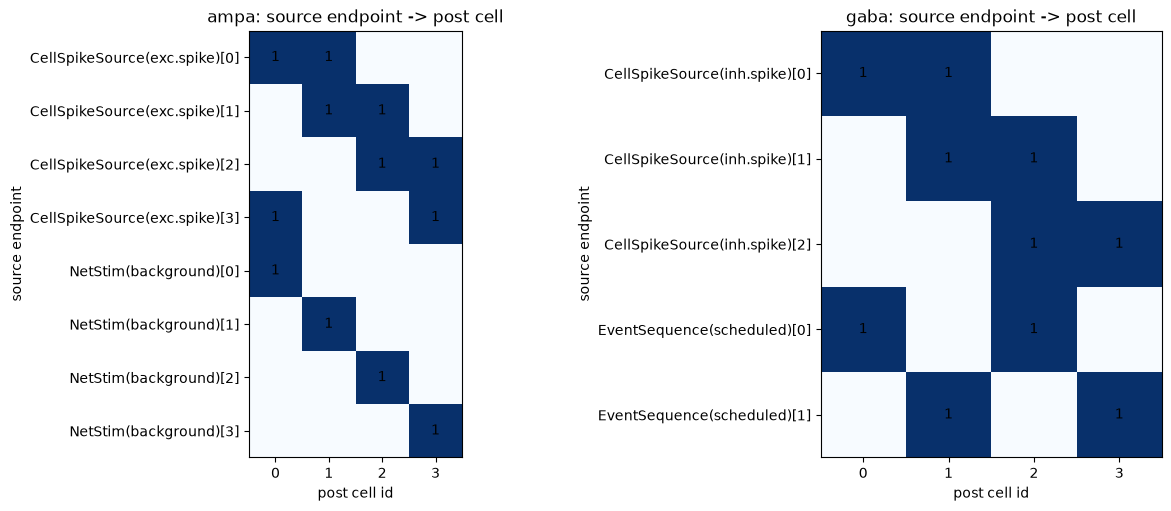

In [7]:
def plot_route_matrix(ax, rows, synapse_name):
    selected = rows[rows.synapse_name == synapse_name].copy()
    selected["source"] = selected.apply(
        lambda row: f"{row.source_type}({row.source_name})[{row.source_id}]", axis=1,
    )
    labels = list(dict.fromkeys(selected.source.tolist()))
    matrix = np.zeros((len(labels), 4), dtype=int)
    label_to_row = {label: index for index, label in enumerate(labels)}
    for row in selected.itertuples():
        matrix[label_to_row[row.source], int(row.post_cell)] += 1
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(1, matrix.max()))
    ax.set(
        title=f"{synapse_name}: source endpoint -> post cell",
        xlabel="post cell id", ylabel="source endpoint",
        xticks=np.arange(4), yticks=np.arange(len(labels)), yticklabels=labels,
    )
    for source_row, post_col in np.argwhere(matrix > 0):
        ax.text(post_col, source_row, str(matrix[source_row, post_col]), ha="center", va="center")
    return image


fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
plot_route_matrix(axes[0], connection_table, "ampa")
plot_route_matrix(axes[1], connection_table, "gaba")
plt.show()

## 4. 组装并运行 Network

Live source 的 owner 必须与 target 一起由同一个 `Network` 推进，所以 `exc`、`inh`、`post` 都加入网络。`NetStim` 和 `EventSequence` 的时间表可以独立求值，不需要伪装成 population。

我们连续调用两次 `run(duration=20 ms)`。第二次从 20 ms 接着运行，不会重新初始化；这也让跨分段的 scheduled event 和 delay buffer 接受实际检验。

In [8]:
network = braincell.Network(name="direct_multi_source_network")
network.add_population("exc", exc)
network.add_population("inh", inh)
network.add_population("post", post)
network.add_population("background", background)
network.add_population("scheduled", scheduled)

first = network.run(
    dt=0.025 * u.ms, duration=20.0 * u.ms,
    event_backend="scatter", spike_recording="population",
)
second = network.run(
    dt=0.025 * u.ms, duration=20.0 * u.ms,
    event_backend="scatter", spike_recording="population",
)

time_ms = np.concatenate([
    first.time.to_decimal(u.ms), second.time.to_decimal(u.ms),
])
exc_spikes = np.concatenate([first.spikes["exc"], second.spikes["exc"]], axis=0)
inh_spikes = np.concatenate([first.spikes["inh"], second.spikes["inh"]], axis=0)
post_voltage = np.concatenate([
    first.traces["post"]["v_soma"].to_decimal(u.mV),
    second.traces["post"]["v_soma"].to_decimal(u.mV),
], axis=0).reshape(len(time_ms), 4)
ampa_g = np.concatenate([
    first.traces["post"]["g_ampa"].to_decimal(u.uS),
    second.traces["post"]["g_ampa"].to_decimal(u.uS),
], axis=0).reshape(len(time_ms), 2, 4).sum(axis=1)
gaba_g = np.concatenate([
    first.traces["post"]["g_gaba"].to_decimal(u.uS),
    second.traces["post"]["g_gaba"].to_decimal(u.uS),
], axis=0).reshape(len(time_ms), 2, 4).sum(axis=1)

assert np.isclose(second.time[0].to_decimal(u.ms), 20.0)
assert int(np.asarray(exc_spikes).sum()) >= 4
assert int(np.asarray(inh_spikes).sum()) >= 3
assert float(ampa_g.max()) > 0.0
assert float(gaba_g.max()) > 0.0

pd.DataFrame({
    "quantity": ["time steps", "exc spikes", "inh spikes", "max AMPA g (uS)", "max GABA g (uS)"],
    "value": [len(time_ms), int(exc_spikes.sum()), int(inh_spikes.sum()), float(ampa_g.max()), float(gaba_g.max())],
})

,quantity,value
0,time steps,1600.000000
1,exc spikes,4.000000
2,inh spikes,3.000000
3,max AMPA g (uS),0.200956
4,max GABA g (uS),0.148566


In [9]:
synapse_layouts = [layout for layout in post.layouts if layout.kind.startswith("synapse:")]
layout_table = pd.DataFrame({
    "layout_id": [layout.id for layout in synapse_layouts],
    "kind": [layout.kind for layout in synapse_layouts],
    "n_active": [layout.n_active for layout in synapse_layouts],
})
assert dict(zip(layout_table.kind, layout_table.n_active)) == {
    "synapse:ExpSyn": 8,
    "synapse:Exp2Syn": 8,
}
layout_table

,layout_id,kind,n_active
0,8,synapse:ExpSyn,8
1,9,synapse:Exp2Syn,8


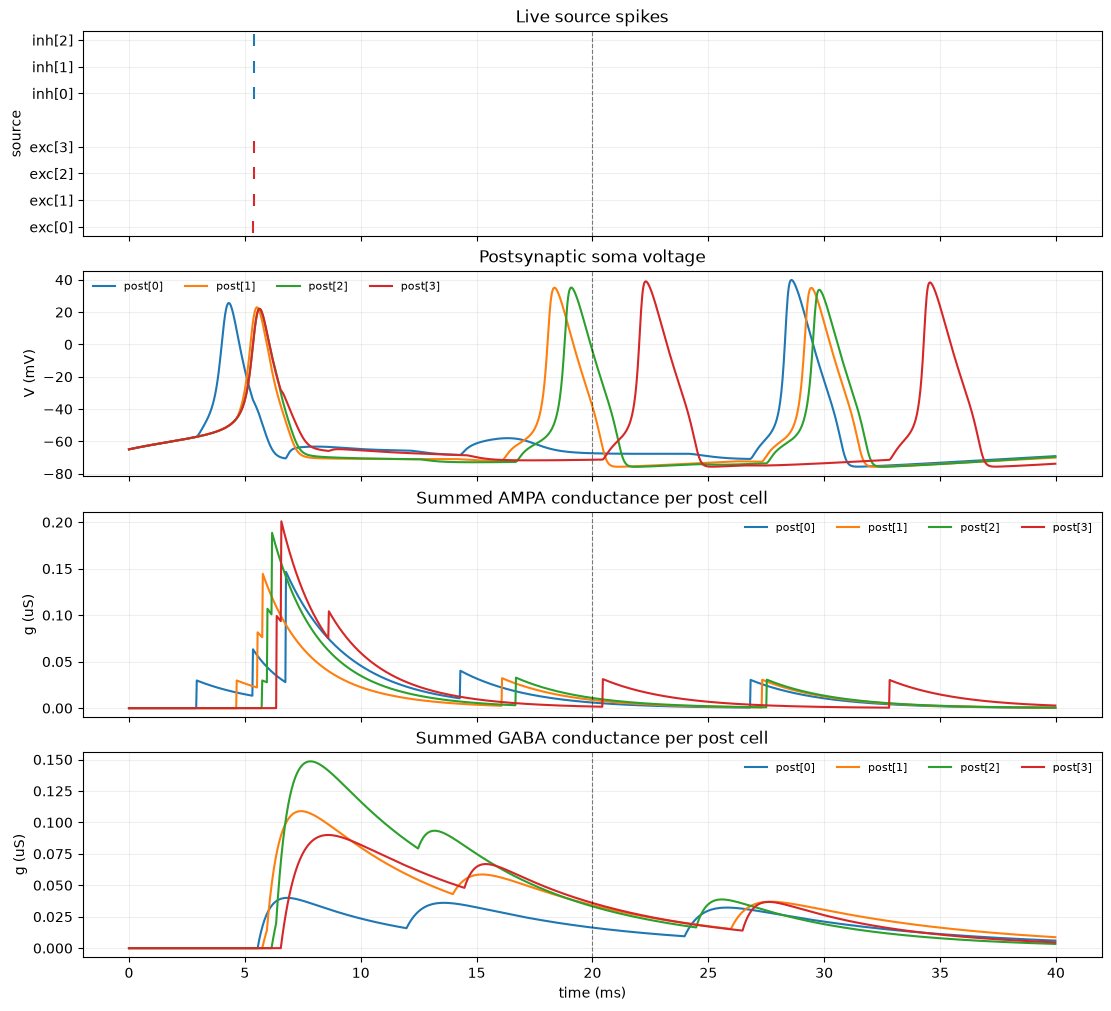

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True, constrained_layout=True)

for cell_id in range(exc_spikes.shape[1]):
    axes[0].scatter(
        time_ms[np.flatnonzero(exc_spikes[:, cell_id])],
        np.full(int(exc_spikes[:, cell_id].sum()), cell_id),
        marker="|", s=80, color="tab:red",
    )
for cell_id in range(inh_spikes.shape[1]):
    axes[0].scatter(
        time_ms[np.flatnonzero(inh_spikes[:, cell_id])],
        np.full(int(inh_spikes[:, cell_id].sum()), cell_id + 5),
        marker="|", s=80, color="tab:blue",
    )
axes[0].set(
    ylabel="source",
    yticks=[0, 1, 2, 3, 5, 6, 7],
    yticklabels=["exc[0]", "exc[1]", "exc[2]", "exc[3]", "inh[0]", "inh[1]", "inh[2]"],
    title="Live source spikes",
)

for cell_id in range(4):
    axes[1].plot(time_ms, post_voltage[:, cell_id], label=f"post[{cell_id}]")
    axes[2].plot(time_ms, ampa_g[:, cell_id], label=f"post[{cell_id}]")
    axes[3].plot(time_ms, gaba_g[:, cell_id], label=f"post[{cell_id}]")

axes[1].set(ylabel="V (mV)", title="Postsynaptic soma voltage")
axes[2].set(ylabel="g (uS)", title="Summed AMPA conductance per post cell")
axes[3].set(ylabel="g (uS)", xlabel="time (ms)", title="Summed GABA conductance per post cell")
for ax in axes:
    ax.axvline(20.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.grid(alpha=0.2)
for ax in axes[1:]:
    ax.legend(ncol=4, frameon=False, fontsize=8)
plt.show()

## 5. 这个例子说明了什么

- `Cell.place()` 负责建立具体 postsynaptic 实例；位置和突触动力学参数属于 synapse。
- `connect()` 负责 source 到 synapse 的逐行事件路由；`weight` 和 `delay` 属于 connection。
- live cell source 和 scheduled source 可以同时汇聚到同一个下游群体。
- 任意稀疏连接都能由重复保序的 source/synapse views 显式表达。
- `Network` 负责共同推进所有 live owner，并延续 runtime state 和待发送事件。
- 更高层的 projection API 将来可以生成同样的 connection rows，但不是这个底层执行路径的前提。